In [31]:
import tensorflow as tf
import numpy as np
from functools import partial
from tensorflow.keras.callbacks import EarlyStopping
import nbimporter
from CIFAR10_MLP import LRFinder, OneCycleScheduler
from sklearn.metrics import confusion_matrix
import seaborn as sns
import math
import matplotlib.pyplot as plt
import keras_tuner as kt

In [2]:
print(tf.__version__)
print("Dostępne urządzenia:", len(tf.config.list_physical_devices('GPU')))

2.21.0
Dostępne urządzenia: 1


W0000 00:00:1787905334.791212     662 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)


### Creating validation set

In [4]:
rng = np.random.default_rng(42)
idx = rng.permutation(len(x_train))
split = int(0.8*len(x_train))
idx_train = idx[:split]
idx_val = idx[split:]

x_val = x_train[idx_val]
y_val = y_train[idx_val]
x_train = x_train[idx_train]
y_train = y_train[idx_train]

print(f"Training set size: X={x_train.shape} Y={y_train.shape}")
print(f"Validation set size: X={x_val.shape} Y={y_val.shape}")
print(f"Test set size: X={x_test.shape} Y={y_test.shape}")

Training set size: X=(40000, 32, 32, 3) Y=(40000, 1)
Validation set size: X=(10000, 32, 32, 3) Y=(10000, 1)
Test set size: X=(10000, 32, 32, 3) Y=(10000, 1)


### Batching the data

In [5]:
train_raw = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(50000, seed=42)
val_raw = tf.data.Dataset.from_tensor_slices((x_val, y_val))
test_raw = tf.data.Dataset.from_tensor_slices((x_test, y_test))

print(len(train_raw), len(test_raw))

W0000 00:00:1787905342.993049     662 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1787905343.111632     662 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13209 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


40000 10000


In [6]:
BATCH_SIZE=32

train32=train_raw.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val32=val_raw.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test32=test_raw.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

### Creating the model

In [7]:
ConvBlock = partial(tf.keras.layers.Conv2D, kernel_size=3, padding='same', kernel_initializer='he_normal', activation='relu')

In [28]:
def add_data_augmentation(model, value_range=[-1,1], translation=0.15, brightness=0.1, contrast=0.1):
    layers=[
        tf.keras.layers.RandomTranslation(translation, translation, seed=42),
        tf.keras.layers.RandomFlip(mode='horizontal',seed=42),
        tf.keras.layers.RandomBrightness(brightness, value_range=value_range, seed=42),
        tf.keras.layers.RandomContrast(contrast, value_range=value_range, seed=42)
           ]
    for layer in layers:
        model.add(layer)

def add_conv_blocks(model):
    layers=[
        ConvBlock(filters=32, use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        
        ConvBlock(filters=32, use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
    
        tf.keras.layers.MaxPool2D(), #16x16
    
        ConvBlock(filters=64, use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
    
        ConvBlock(filters=64, use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
    
        tf.keras.layers.MaxPool2D(), #8x8
    
        ConvBlock(filters=128, use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
    
        ConvBlock(filters=128, use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
    
        ConvBlock(filters=128, use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
    
        tf.keras.layers.MaxPool2D(), #4x4
    ]

    for layer in layers:
        model.add(layer)

def add_FC_layers(model, dropout):
    layers=[
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, kernel_initializer='he_normal', activation='relu'),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(64, kernel_initializer='he_normal', activation='relu'),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(10, activation='softmax')
    ]

    for layer in layers:
        model.add(layer)

def build_model(dropout: float=0.5):
    model=tf.keras.Sequential()
    model.add(tf.keras.layers.Rescaling(2./255, offset=-1))
    add_data_augmentation(model)
    add_conv_blocks(model)
    add_FC_layers(model, dropout)
    return model
    


In [11]:
model = build_model()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [16]:
earlyStop=EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [17]:
history=model.fit(
    train32,
    epochs=100,
    validation_data=val32,
    callbacks=[earlyStop]
)


Epoch 1/100


/home/nagorny/miniconda3/envs/tf_gpu_wsl/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1787567437.206828    1353 cuda_dnn.cc:461] Loaded cuDNN version 92400


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.1221 - loss: 2.3082 - val_accuracy: 0.2302 - val_loss: 2.2065
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.2247 - loss: 1.9919 - val_accuracy: 0.3035 - val_loss: 1.8327
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.2979 - loss: 1.7866 - val_accuracy: 0.3997 - val_loss: 1.6127
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.3686 - loss: 1.6625 - val_accuracy: 0.4769 - val_loss: 1.4253
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.4334 - loss: 1.5410 - val_accuracy: 0.5278 - val_loss: 1.3483
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.5002 - loss: 1.4116 - val_accuracy: 0.5902 - val_loss: 1.1507
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.5513 - loss: 1.2915 - val_accuracy: 0.6206 - val_loss: 1.0486
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.5778 - los

In [9]:
def learning_process(history):
    plt.figure
    plt.tight_layout()
    
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title("Loss Function")
    plt.xlabel("Epochs")
    plt.legend()
    
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='Train acc')
    plt.plot(history.history['val_accuracy'], label='Val acc')
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()
    
    plt.show()

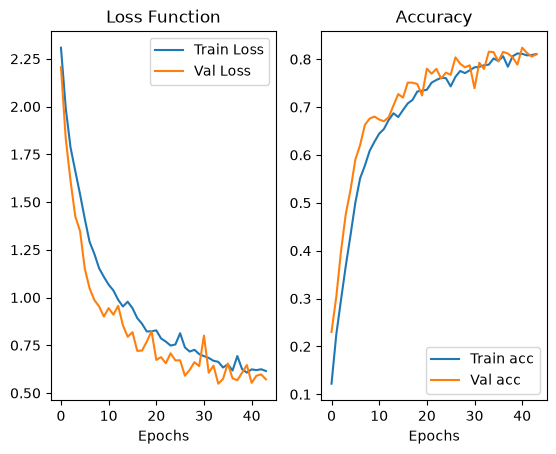

In [19]:
learning_process(history)

In [24]:
#model.save_weights('CNN_steadyLR_AUG.weights.h5')

In [25]:
loss, accuracy = model.evaluate(test32)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s -196us/step - accuracy: 0.8485 - loss: 0.4877


I0000 00:00:1787568940.354453    1643 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 3012231862038226348
I0000 00:00:1787568940.354493    1643 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 16169314469743337186
I0000 00:00:1787568940.354496    1643 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 15901014323757504470


In [11]:
lrfinder=LRFinder(start_lr=1e-5, end_lr=1, max_steps=5000)
#history = model.fit(train32, epochs=4, callbacks=[lrfinder])
#lrfinder.plot()

In [100]:
batch_size=32
n_epochs = 100
onecycle = OneCycleScheduler(math.ceil(len(x_train) / batch_size) * n_epochs,
                             max_lr=0.004)
history = model.fit(train32, epochs=n_epochs, batch_size=batch_size,
                    validation_data=val32,
                    callbacks=[onecycle])

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.2900 - loss: 1.9051 - val_accuracy: 0.4405 - val_loss: 1.5420
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - accuracy: 0.4309 - loss: 1.5485 - val_accuracy: 0.5233 - val_loss: 1.3292
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.5135 - loss: 1.3543 - val_accuracy: 0.5848 - val_loss: 1.1771
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.5766 - loss: 1.2107 - val_accuracy: 0.5325 - val_loss: 1.3710
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.6285 - loss: 1.0795 - val_accuracy: 0.6510 - val_loss: 1.0056
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.6620 - loss: 0.9927 - val_accuracy: 0.6767 - val_loss: 0.9405
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.6893 - loss: 0.9171 - val_accuracy: 0.6760 - val_loss: 0.9662
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 

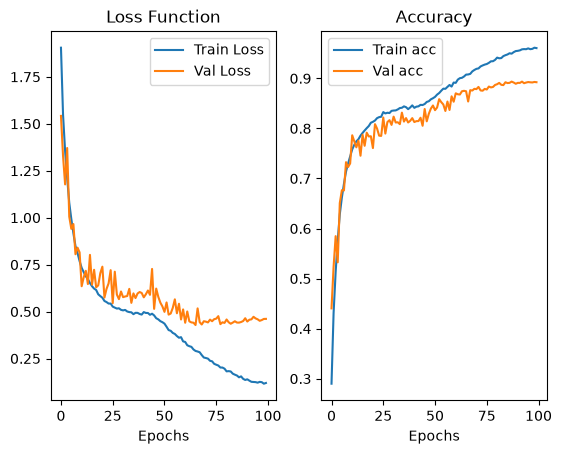

In [101]:
learning_process(history)

In [102]:
model.save('cnn_89percent.keras')

In [103]:
loss, accuracy = model.evaluate(test32)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8923 - loss: 0.4660


### Increasing batch_size to make learning curve smoother

In [10]:
BATCH_SIZE = 64

train64 = train_raw.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val64 = val_raw.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test64 = test_raw.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [45]:
model64=build_model()
model64.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

Epoch 1/8


/home/nagorny/miniconda3/envs/tf_gpu_wsl/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.1095 - loss: 3.1447
Epoch 2/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.1147 - loss: 2.3082
Epoch 3/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.1425 - loss: 2.2587
Epoch 4/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.1909 - loss: 2.1239
Epoch 5/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.2367 - loss: 1.9818
Epoch 6/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.1966 - loss: 2.0831
Epoch 7/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.1129 - loss: 2.4619
Epoch 8/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.0994 - loss: 2.3465


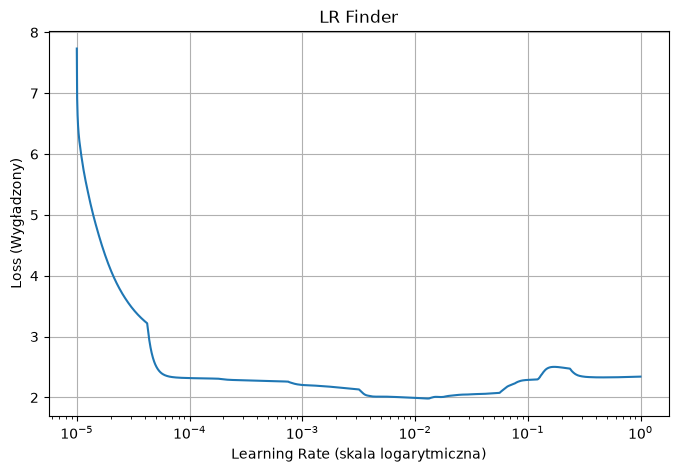

In [46]:
lrfinder=LRFinder(start_lr=1e-5, end_lr=1, max_steps=5000)
history = model64.fit(train64, epochs=8, callbacks=[lrfinder])
lrfinder.plot()

In [11]:
model64=build_model()
model64.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=4e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history64=model64.fit(train64, epochs=100, callbacks=[earlyStop], validation_data=val64, batch_size=64) 

NameError: name 'earlyStop' is not defined

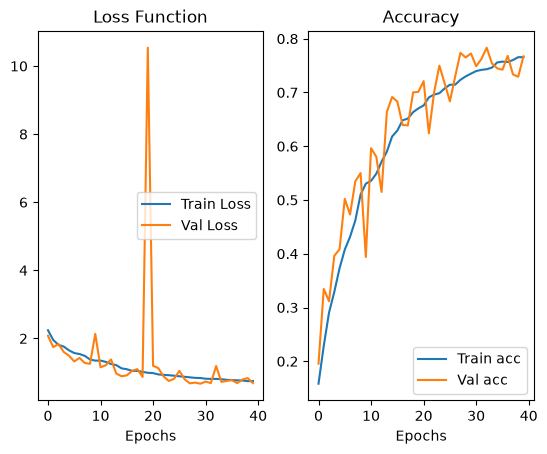

In [48]:
learning_process(history64)

In [50]:
loss, acc = model64.evaluate(test64)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7691 - loss: 0.6990


In [12]:
model64_1c=build_model(0.15)
model64_1c.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
batch_size=64
n_epochs =100
onecycle = OneCycleScheduler(math.ceil(len(x_train) / batch_size) * n_epochs,
                             max_lr=7e-3)
history = model64_1c.fit(train64, epochs=n_epochs, batch_size=batch_size,
                    validation_data=val64,
                    callbacks=[onecycle])

Epoch 1/1000


/home/nagorny/miniconda3/envs/tf_gpu_wsl/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1787600773.615724     648 cuda_dnn.cc:461] Loaded cuDNN version 92400


625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.2990 - loss: 1.8633 - val_accuracy: 0.4428 - val_loss: 1.5337
Epoch 2/1000
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.4430 - loss: 1.5070 - val_accuracy: 0.5133 - val_loss: 1.3567
Epoch 3/1000
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.5285 - loss: 1.3088 - val_accuracy: 0.5924 - val_loss: 1.1373
Epoch 4/1000
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.5951 - loss: 1.1557 - val_accuracy: 0.6424 - val_loss: 1.0048
Epoch 5/1000
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6447 - loss: 1.0306 - val_accuracy: 0.6240 - val_loss: 1.1134
Epoch 6/1000
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.6802 - loss: 0.9405 - val_accuracy: 0.7191 - val_loss: 0.8138
Epoch 7/1000
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.7072 - loss: 0.8712 - val_accuracy: 0.7378 - val_loss: 0.7637
Epoch 8/1000
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.7310 - loss: 0.7977

In [13]:
loss, acc = model64_1c.evaluate(test64)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8997 - loss: 1.2065


In [15]:
model64_1c.save_weights('model64_1c.weights.h5')

ValueError: You are loading weights into a model that has not yet been built. Try building the model first by calling it on some data or by using `build()`.

### Allegedly SGD optimizer allows vgg models to achieve better scores

In [22]:
model_SGD = build_model(0.15)

model_SGD.compile(optimizer=tf.keras.optimizers.SGD(momentum=0.9), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

Epoch 1/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.1198 - loss: 2.6142
Epoch 2/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.2382 - loss: 2.0111
Epoch 3/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.3183 - loss: 1.8388
Epoch 4/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.1646 - loss: 2.2148


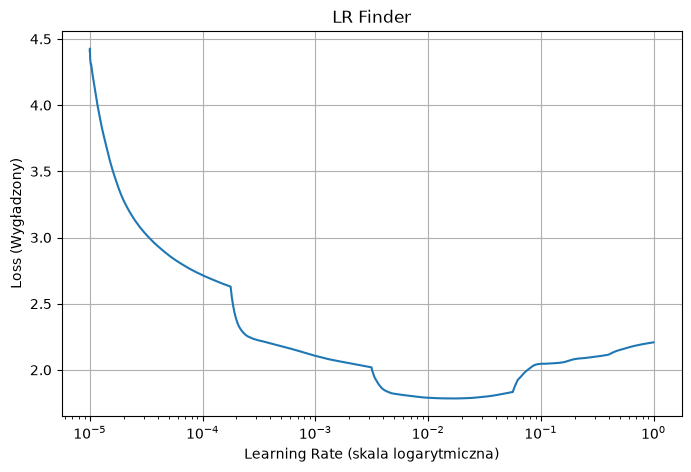

In [31]:
lrfinder=LRFinder(start_lr=1e-5, end_lr=1, max_steps=5000)
model_SGD.fit(train32, epochs=4, callbacks=[lrfinder])
lrfinder.plot()

In [24]:
batch_size=32
n_epochs =20
onecycle = OneCycleScheduler(math.ceil(len(x_train) / batch_size) * n_epochs,
                             max_lr=1e-2)
history = model_SGD.fit(train32, epochs=n_epochs, batch_size=batch_size,
                    validation_data=val32,
                    callbacks=[onecycle])

Epoch 1/20


/home/nagorny/miniconda3/envs/tf_gpu_wsl/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.2540 - loss: 1.9819 - val_accuracy: 0.3931 - val_loss: 1.6568
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.3915 - loss: 1.6397 - val_accuracy: 0.4966 - val_loss: 1.3853
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.4665 - loss: 1.4714 - val_accuracy: 0.5351 - val_loss: 1.3132
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.5181 - loss: 1.3435 - val_accuracy: 0.5142 - val_loss: 1.4168
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.5693 - loss: 1.2234 - val_accuracy: 0.6029 - val_loss: 1.1554
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.6115 - loss: 1.1304 - val_accuracy: 0.6835 - val_loss: 0.9028
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.6429 - loss: 1.0538 - val_accuracy: 0.6276 - val_loss: 1.1896
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.6701 - loss: 0.98

In [25]:
model_SGD.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_4            │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_4 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness_4             │ (None, 32, 32, 3)      │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_4               │ (None, 32, 32, 3)      │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_29 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_30 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_31 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 1,413,846 (5.39 MB)

 Trainable params: 706,346 (2.69 MB)

 Non-trainable params: 1,152 (4.50 KB)

 Optimizer params: 706,348 (2.69 MB)

In [20]:
loss, acc = model_SGD.evaluate(test32)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8919 - loss: 0.4114


### Using Global Average Pooling instead of FC layers to reduce number of parameters and prevent overfitting

In [11]:
def build_model_GAP(data_augmentation=True):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Rescaling(2./255, offset=-1))
    if data_augmentation:
        add_data_augmentation(model)
    add_conv_blocks(model)
    model.add(tf.keras.layers.GlobalAveragePooling2D())
    model.add(tf.keras.layers.Dense(10, activation='softmax'))
    return model

In [27]:
model_gap=build_model_GAP()
model_gap.compile(optimizer=tf.keras.optimizers.Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

Epoch 1/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.2808 - loss: 2.0007
Epoch 2/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.4541 - loss: 1.5171
Epoch 3/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.4727 - loss: 1.4899
Epoch 4/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.1822 - loss: 2.2948


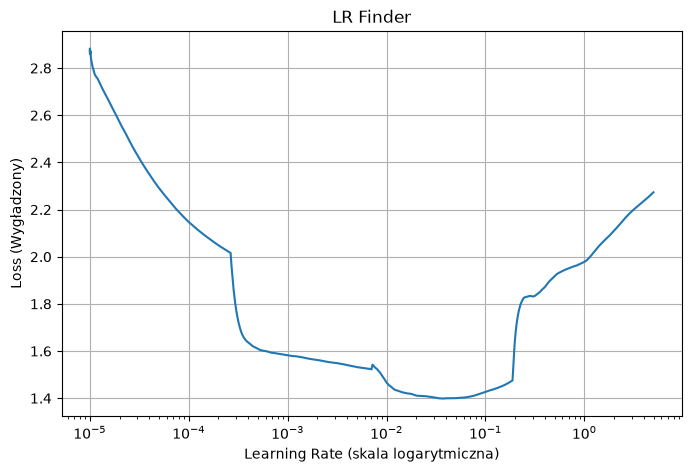

In [29]:
lrfinder=LRFinder(start_lr=1e-5, end_lr=5, max_steps=5000)
model_gap.fit(train32, epochs=4, callbacks=[lrfinder])
lrfinder.plot()

In [31]:
model_gap=build_model_GAP()
model_gap.compile(optimizer=tf.keras.optimizers.Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

batch_size=32
n_epochs =50
onecycle = OneCycleScheduler(math.ceil(len(x_train) / batch_size) * n_epochs,
                             max_lr=3e-2)
history = model_gap.fit(train32, epochs=n_epochs, batch_size=batch_size,
                    validation_data=val32,
                    callbacks=[onecycle])

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step - accuracy: 0.4598 - loss: 1.5006 - val_accuracy: 0.5258 - val_loss: 1.4028
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.6230 - loss: 1.0762 - val_accuracy: 0.6760 - val_loss: 0.9449
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.6856 - loss: 0.9104 - val_accuracy: 0.5950 - val_loss: 1.2838
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.7157 - loss: 0.8218 - val_accuracy: 0.7137 - val_loss: 0.8463
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.7345 - loss: 0.7765 - val_accuracy: 0.6943 - val_loss: 0.9344
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.7471 - loss: 0.7326 - val_accuracy: 0.6311 - val_loss: 1.3038
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.7596 - loss: 0.7017 - val_accuracy: 0.7706 - val_loss: 0.6835
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.7699 -

In [32]:
model_gap.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_6 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_5            │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_5 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness_5             │ (None, 32, 32, 3)      │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_5               │ (None, 32, 32, 3)      │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_42 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_43 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_44 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_45 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 1,310,528 (5.00 MB)

 Trainable params: 436,458 (1.66 MB)

 Non-trainable params: 1,152 (4.50 KB)

 Optimizer params: 872,918 (3.33 MB)

In [36]:
loss, acc =model_gap.evaluate(test32)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9013 - loss: 0.4832


In [37]:
model_gap.save_weights('model_gap.weights.h5')

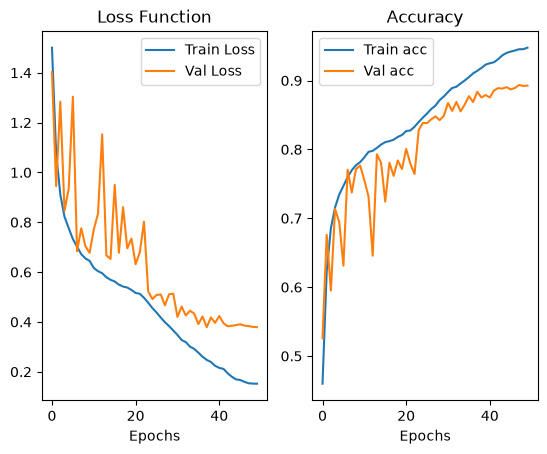

In [34]:
learning_process(history)

### Testing if model requires one more conv block

In [13]:
earlystop_t=EarlyStopping(monitor='accuracy', patience=10, mode="max", restore_best_weights=True)

In [14]:
model_t=build_model_GAP(data_augmentation=False)
model_t.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.007), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model_t.fit(train32, epochs=500, callbacks=[earlystop_t])

Epoch 1/500


/home/nagorny/miniconda3/envs/tf_gpu_wsl/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1787684508.122255   32323 service.cc:153] XLA service 0x78049c03f130 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787684508.122281   32323 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1787684508.199456   32323 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787684508.597433   32323 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1787684508.628711   32323 dot_merger

  57/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.2259 - loss: 2.2194

I0000 00:00:1787684513.577423   32323 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.4913 - loss: 1.4046
Epoch 2/500
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6839 - loss: 0.9039
Epoch 3/500
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7542 - loss: 0.7184
Epoch 4/500
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7896 - loss: 0.6133
Epoch 5/500
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8183 - loss: 0.5299
Epoch 6/500
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8407 - loss: 0.4572
Epoch 7/500
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8593 - loss: 0.4002
Epoch 8/500
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8801 - loss: 0.3411
Epoch 9/500
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8968 - loss: 0.2921
Epoch 10/500
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9137 - loss: 0.2487
Epoch 11/500
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9204 - loss: 0.2245
Epoch 12/500
1250/1250 ━━━━━━━

Conclusion: model has enough capacity to fully learn the training data, so one conv block is not needed.

### Changing [-1,1] scaling to standardization

In [19]:
rescale=tf.keras.layers.Rescaling(1./255)
norm=tf.keras.layers.Normalization()
norm.adapt(rescale(x_train))

In [12]:
def build_model_Normalized():
    model=tf.keras.Sequential()

    model.add(
        rescale
    )
    
    add_data_augmentation(model, value_range=[0,1])
    
    model.add(
        norm
    )
    
    add_conv_blocks(model)
    model.add(
        tf.keras.layers.GlobalAveragePooling2D()
    )
    
    model.add(
        tf.keras.layers.Dense(10, activation='softmax')
    )
    return model

Epoch 1/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.3356 - loss: 1.8939
Epoch 2/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.4762 - loss: 1.4566
Epoch 3/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.5325 - loss: 1.3286
Epoch 4/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.3873 - loss: 1.7114


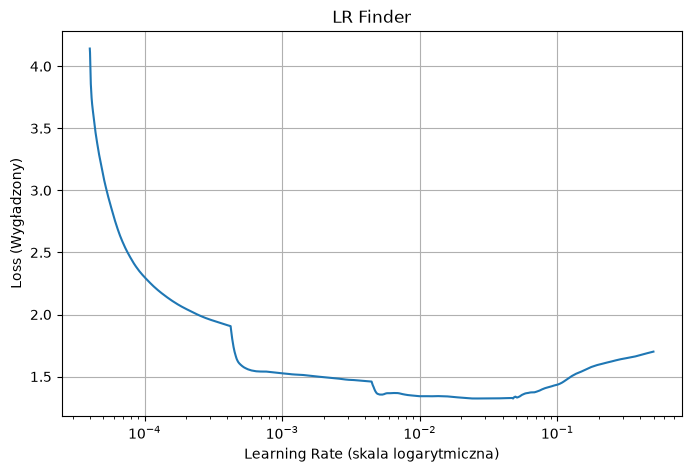

In [68]:
model=build_model_Normalized()
model.compile(optimizer=tf.keras.optimizers.Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

lrfinder=LRFinder(start_lr=4e-5, end_lr=5e-1, max_steps=5000)
model.fit(train32, epochs=4 ,batch_size=32, callbacks=[lrfinder])
lrfinder.plot()

In [28]:
model=build_model_Normalized()
model.compile(optimizer=tf.keras.optimizers.Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

n_epochs=50
batch_size=32
onecycle=OneCycleScheduler(math.ceil(len(x_train)/batch_size)*n_epochs,
                           max_lr=7e-3)

history=model.fit(train32, batch_size=batch_size, epochs=n_epochs, validation_data=val32, callbacks=[onecycle])

Epoch 1/50


/home/nagorny/miniconda3/envs/tf_gpu_wsl/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.4429 - loss: 1.5353 - val_accuracy: 0.5048 - val_loss: 1.5418
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.5979 - loss: 1.1424 - val_accuracy: 0.6253 - val_loss: 1.1314
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.6782 - loss: 0.9323 - val_accuracy: 0.6915 - val_loss: 0.9120
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.7157 - loss: 0.8218 - val_accuracy: 0.7109 - val_loss: 0.9033
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.7426 - loss: 0.7504 - val_accuracy: 0.6947 - val_loss: 0.9231
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.7603 - loss: 0.7013 - val_accuracy: 0.7693 - val_loss: 0.7294
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.7734 - loss: 0.6603 - val_accuracy: 0.7208 - val_loss: 0.8735
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.7835 - loss: 0.63

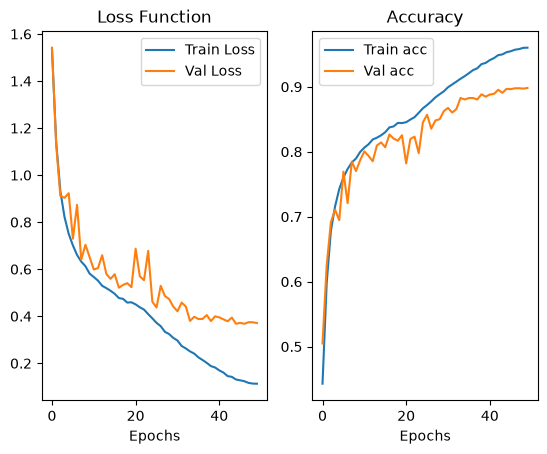

In [29]:
learning_process(history)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


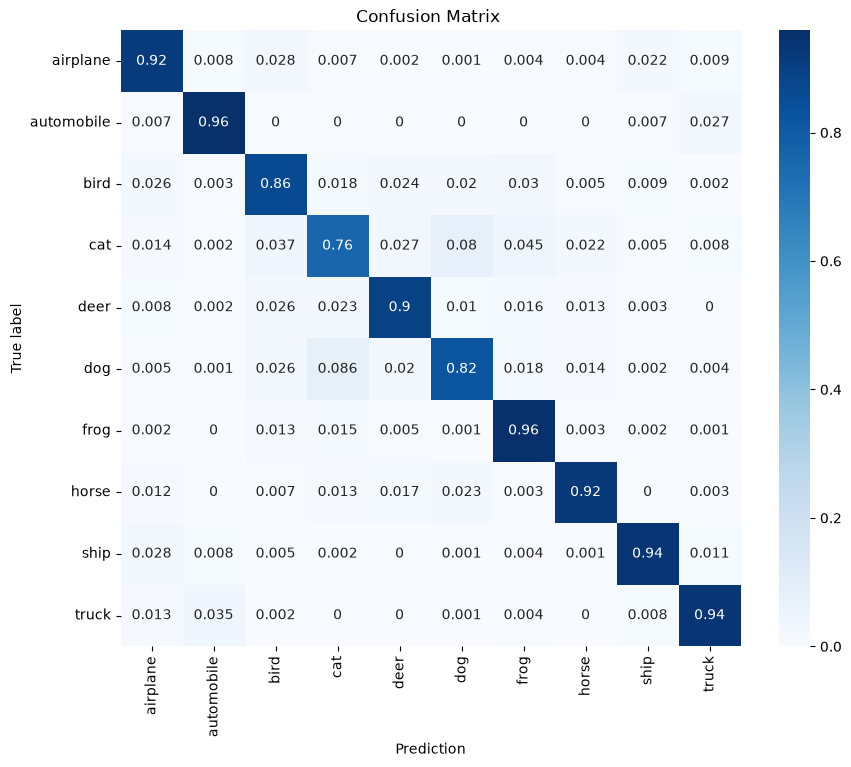

In [30]:
classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

def printConfusionMatrix(model, name: str= ""):
    y_pred = np.argmax(model.predict(x_test), axis=1)
    cm = confusion_matrix(y_test, y_pred, normalize='true')
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Prediction')
    plt.ylabel('True label')
    plt.title('Confusion Matrix '+name)
    plt.show()

printConfusionMatrix(model)

In [31]:
loss, acc = model.evaluate(test32)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8977 - loss: 0.3786


### Adding Label smoothing

In [13]:
def sparse_cce_with_label_smoothing(num_classes, label_smoothing=0.1):

    cce = tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=label_smoothing
    )

    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true = tf.squeeze(y_true, axis=-1)
        y_true = tf.one_hot(y_true, depth=num_classes)

        return cce(y_true, y_pred)

    return loss

Epoch 1/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.3340 - loss: 1.9659
Epoch 2/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.4824 - loss: 1.6422
Epoch 3/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.5306 - loss: 1.5595
Epoch 4/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.3555 - loss: 1.9171


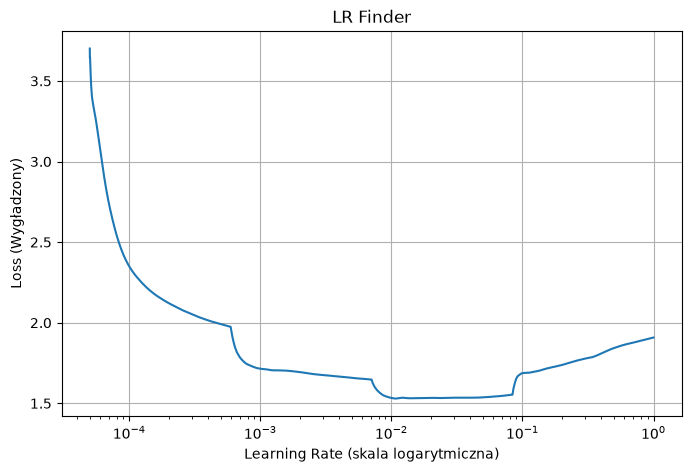

In [78]:
model=build_model_Normalized()
model.compile(optimizer=tf.keras.optimizers.Adam(), loss=sparse_cce_with_label_smoothing(num_classes=10, label_smoothing=0.1), metrics=['accuracy'])

lrfinder=LRFinder(start_lr=5e-5, end_lr=1, max_steps=5000)
model.fit(train32, epochs=4, callbacks=[lrfinder])
lrfinder.plot()

In [80]:
model=build_model_Normalized()
model.compile(optimizer=tf.keras.optimizers.Adam(), loss=sparse_cce_with_label_smoothing(num_classes=10, label_smoothing=0.1), metrics=['accuracy'])

n_epochs=50
batch_size=32

onecycle=OneCycleScheduler(math.ceil(len(x_train)/batch_size)*n_epochs,
                           max_lr=1e-2)
history=model.fit(train32, batch_size=batch_size, epochs=n_epochs, validation_data=val32, callbacks=[onecycle], shuffle=False)

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step - accuracy: 0.4486 - loss: 1.7067 - val_accuracy: 0.5480 - val_loss: 1.6271
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.6122 - loss: 1.3877 - val_accuracy: 0.5981 - val_loss: 1.4487
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.6850 - loss: 1.2357 - val_accuracy: 0.6732 - val_loss: 1.2875
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.7190 - loss: 1.1658 - val_accuracy: 0.6628 - val_loss: 1.3773
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.7443 - loss: 1.1166 - val_accuracy: 0.7371 - val_loss: 1.1295
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.7600 - loss: 1.0801 - val_accuracy: 0.7308 - val_loss: 1.1567
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.7773 - loss: 1.0491 - val_accuracy: 0.7714 - val_loss: 1.0740
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.7835 -

In [81]:
loss, acc = model.evaluate(test32)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8990 - loss: 0.7744


In [36]:
#model.save_weights('CNN_Std_LS.weights.h5')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


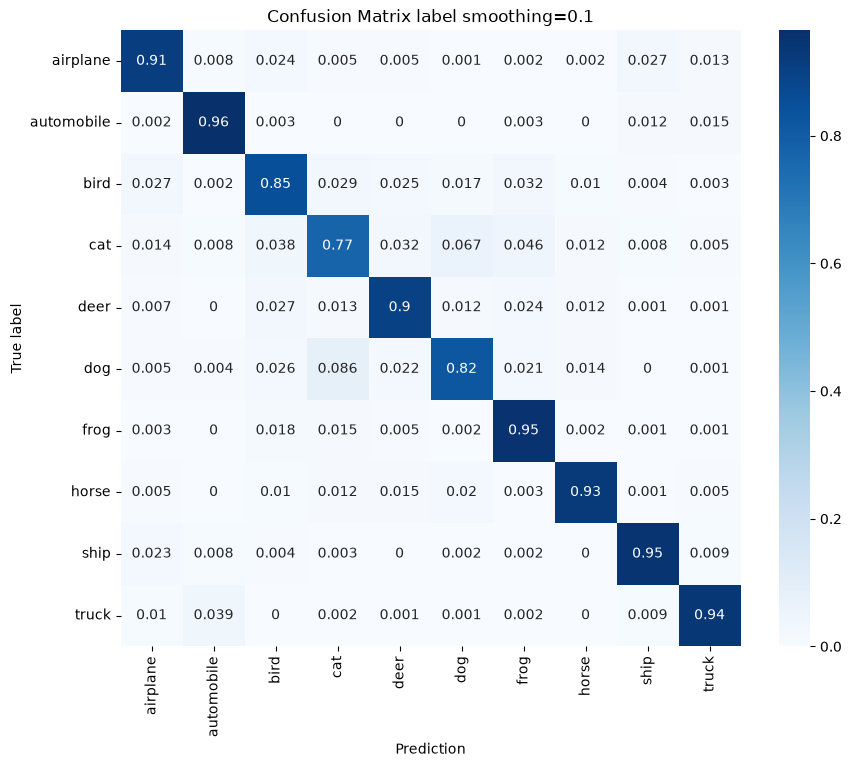

In [39]:
printConfusionMatrix(model, "label smoothing=0.1")

Epoch 1/4


/home/nagorny/miniconda3/envs/tf_gpu_wsl/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.3247 - loss: 2.0829
Epoch 2/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.4764 - loss: 1.7993
Epoch 3/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.5319 - loss: 1.7248
Epoch 4/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - accuracy: 0.3730 - loss: 1.9789


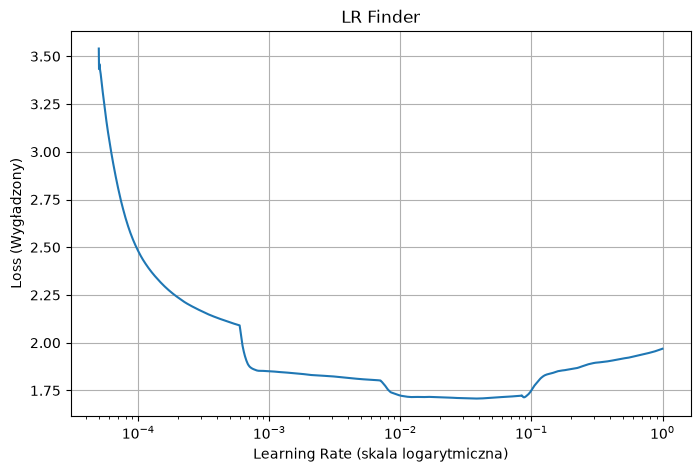

In [38]:
model3=build_model_Normalized()
model3.compile(optimizer=tf.keras.optimizers.Adam(), loss=sparse_cce_with_label_smoothing(num_classes=10, label_smoothing=0.2), metrics=['accuracy'])

lrfinder=LRFinder(start_lr=5e-5, end_lr=1, max_steps=5000)
model3.fit(train32, epochs=4, callbacks=[lrfinder])
lrfinder.plot()

In [40]:
model3=build_model_Normalized()
model3.compile(optimizer=tf.keras.optimizers.Adam(), loss=sparse_cce_with_label_smoothing(num_classes=10, label_smoothing=0.2), metrics=['accuracy'])

n_epochs=50
batch_size=32

onecycle = OneCycleScheduler(math.ceil(len(x_train)/batch_size)*n_epochs, max_lr=9e-3)
history=model3.fit(train32, batch_size=batch_size, epochs=n_epochs, callbacks=[onecycle], validation_data=val32, shuffle=False)

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.4442 - loss: 1.8499 - val_accuracy: 0.5325 - val_loss: 1.7387
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - accuracy: 0.6110 - loss: 1.5897 - val_accuracy: 0.6752 - val_loss: 1.5108
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.6863 - loss: 1.4744 - val_accuracy: 0.6529 - val_loss: 1.5961
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.7204 - loss: 1.4134 - val_accuracy: 0.7375 - val_loss: 1.4037
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.7479 - loss: 1.3728 - val_accuracy: 0.7708 - val_loss: 1.3359
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - accuracy: 0.7632 - loss: 1.3410 - val_accuracy: 0.7079 - val_loss: 1.5317
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.7789 - loss: 1.3185 - val_accuracy: 0.7357 - val_loss: 1.3899
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.7879 -

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


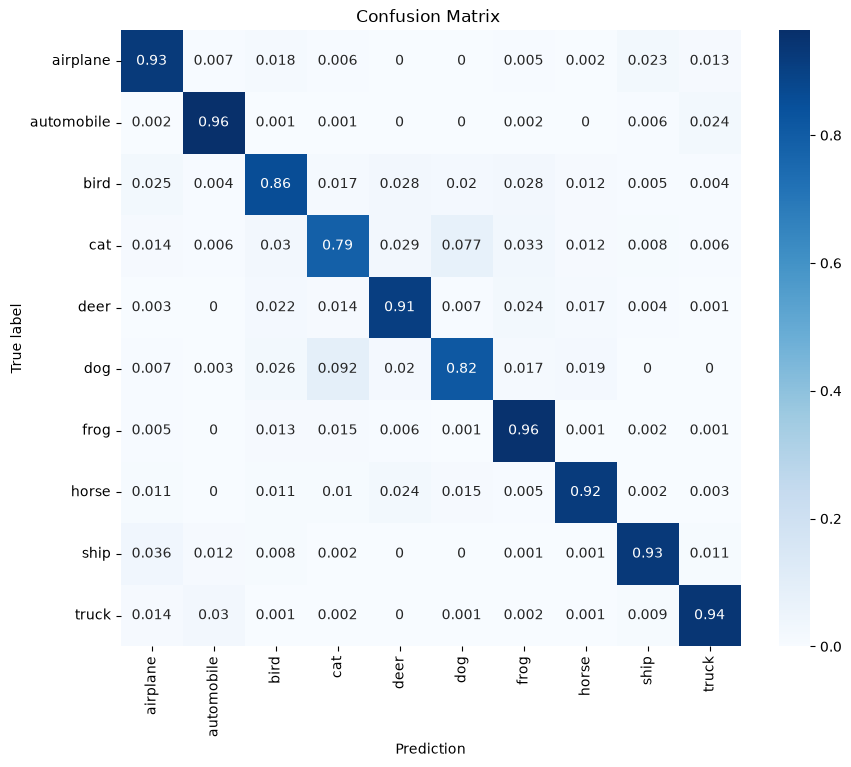

In [41]:
printConfusionMatrix(model3)

In [42]:
loss, acc = model3.evaluate(test32)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9000 - loss: 1.0846


In [44]:
model3.save_weights('CNN_Std_LS02.weights.h5')

Adding label_smoothing didn't improve models accuracy (change is so small it's negligible), although it forces model to give less extremal probabilities while predicting

### Expansing data augmentation via adding RandomErasing to make model find alternative features for the same class

In [32]:
def add_expanded_data_augmentation(model, value_range=[-1,1],translation=0.15, brightness=0.1, contrast=0.1):
    add_data_augmentation(model, value_range)
    model.add(
        tf.keras.layers.RandomErasing(factor=1, scale=(0.02, 0.33), value_range=[0,1], seed=42)
    )

def build_model_Normalized_ExtraAug():
    model=tf.keras.Sequential()
    model.add(
        rescale
    )
    
    add_expanded_data_augmentation(model, value_range=[0,1])
    
    
    model.add(
        norm
    )
    
    add_conv_blocks(model)
    model.add(
        tf.keras.layers.GlobalAveragePooling2D()
    )
    
    model.add(
        tf.keras.layers.Dense(10, activation='softmax')
    )
    return model

### Testing expanded data augmentation

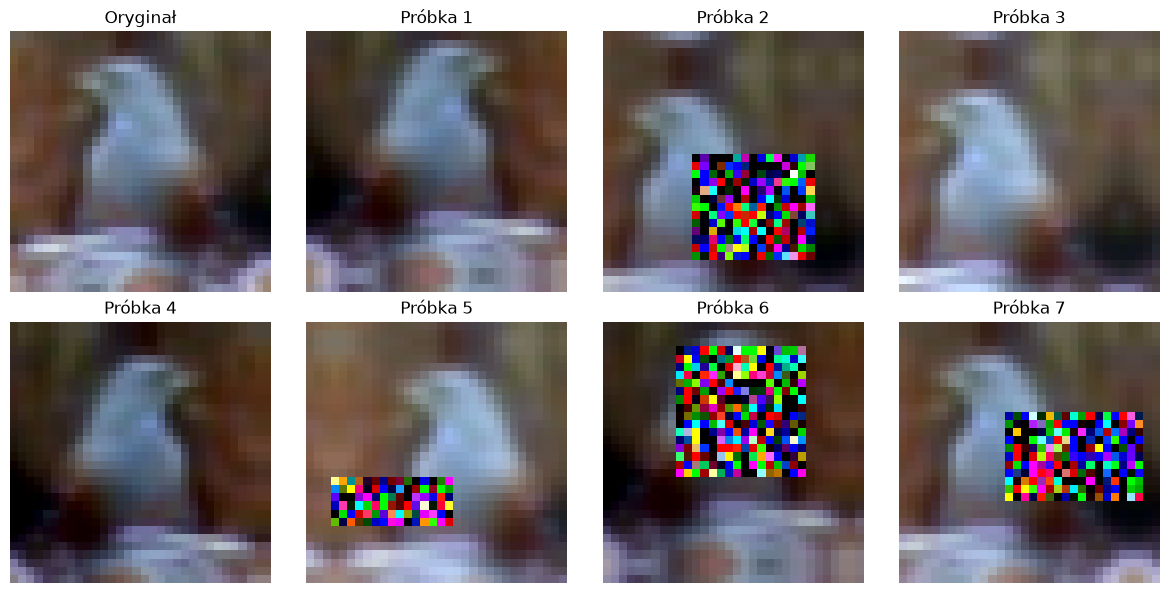

In [80]:
model = tf.keras.Sequential()
model.add(rescale)
add_expanded_data_augmentation(model)

sample_image=x_train[4]
input_image = tf.expand_dims(sample_image, 0)
plt.figure(figsize=(12, 6))

# Obraz oryginalny
plt.subplot(2, 4, 1)
plt.imshow(sample_image)
plt.title("Oryginał")
plt.axis("off")

for i in range(7):
    augmented_image = model(input_image, training=True)

    plt.subplot(2, 4, i + 2)
    plt.imshow(tf.squeeze(augmented_image))
    plt.title(f"Próbka {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()


Epoch 1/4


/home/nagorny/miniconda3/envs/tf_gpu_wsl/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1787832791.116297     744 cuda_dnn.cc:461] Loaded cuDNN version 92400


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.3030 - loss: 1.8878
Epoch 2/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.4387 - loss: 1.5539
Epoch 3/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.4537 - loss: 1.5212
Epoch 4/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.2716 - loss: 1.9528


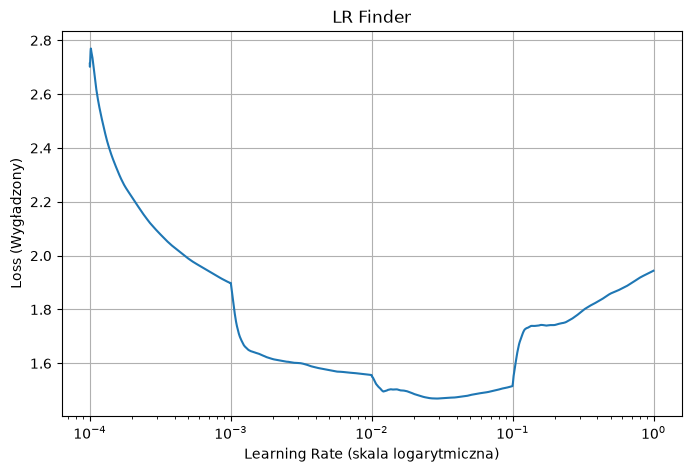

In [81]:
model4=build_model_Normalized_ExtraAug()
model4.compile(optimizer=tf.keras.optimizers.Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lrfinder=LRFinder(start_lr=1e-4, end_lr=1, max_steps=5000)
model4.fit(train32, epochs=4, callbacks=[lrfinder])
lrfinder.plot()

In [83]:
model4=build_model_Normalized_ExtraAug()
model4.compile(optimizer=tf.keras.optimizers.Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

n_epochs=50
batch_size=32

onecycle = OneCycleScheduler(math.ceil(len(x_train)/batch_size)*n_epochs, max_lr=3e-2)
history=model4.fit(train32, batch_size=batch_size, epochs=n_epochs, callbacks=[onecycle], validation_data=val32, shuffle=False)

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.3866 - loss: 1.6678 - val_accuracy: 0.4652 - val_loss: 1.5009
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.5442 - loss: 1.2852 - val_accuracy: 0.5656 - val_loss: 1.2626
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.6095 - loss: 1.1151 - val_accuracy: 0.6213 - val_loss: 1.1651
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.6480 - loss: 1.0111 - val_accuracy: 0.6923 - val_loss: 0.9021
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.6667 - loss: 0.9590 - val_accuracy: 0.7219 - val_loss: 0.8241
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.6812 - loss: 0.9157 - val_accuracy: 0.6572 - val_loss: 0.9862
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.6925 - loss: 0.8809 - val_accuracy: 0.7268 - val_loss: 0.8226
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.7086 -

In [84]:
loss, acc =model4.evaluate(test32)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8904 - loss: 0.3444


In [85]:
model4.save_weights('CNN_Std_ExAUG.weights.h5')

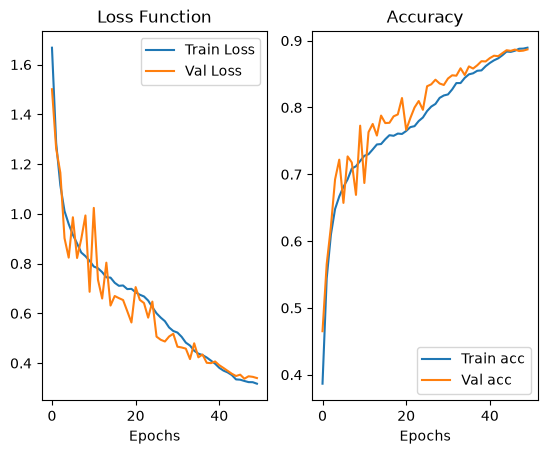

In [86]:
learning_process(history)

With expanded data augmentation model has higher regularization. At the end of the 50 epochs training, both val and train accuracy still rise (and their loss function continue decreasing), which suggests that model may benefit from training a little longer.

In [87]:
model4=build_model_Normalized_ExtraAug()
model4.compile(optimizer=tf.keras.optimizers.Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

n_epochs=100
batch_size=32

onecycle = OneCycleScheduler(math.ceil(len(x_train)/batch_size)*n_epochs, max_lr=3e-2)
history=model4.fit(train32, batch_size=batch_size, epochs=n_epochs, callbacks=[onecycle], validation_data=val32, shuffle=False)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 17ms/step - accuracy: 0.3909 - loss: 1.6676 - val_accuracy: 0.3977 - val_loss: 2.3294
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.5461 - loss: 1.2760 - val_accuracy: 0.6486 - val_loss: 1.0119
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.6202 - loss: 1.0828 - val_accuracy: 0.6163 - val_loss: 1.2752
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.6539 - loss: 0.9891 - val_accuracy: 0.7088 - val_loss: 0.8977
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.6779 - loss: 0.9272 - val_accuracy: 0.7109 - val_loss: 0.8756
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.6923 - loss: 0.8817 - val_accuracy: 0.7141 - val_loss: 0.8405
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.7075 - loss: 0.8472 - val_accuracy: 0.7324 - val_loss: 0.8002
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 

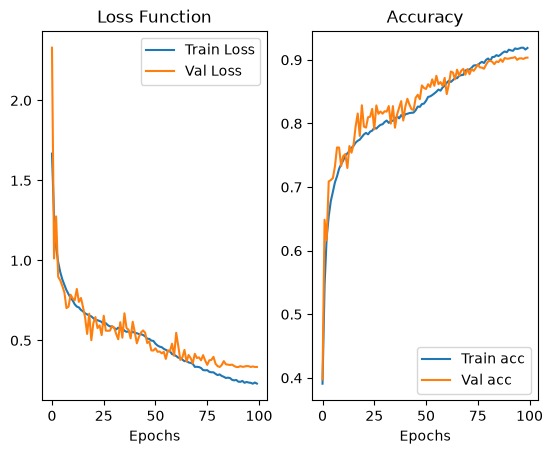

In [88]:
learning_process(history)

In [90]:
loss, acc =model4.evaluate(test32)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9019 - loss: 0.3419


In [91]:
model4.save_weights('CNN_Std_ExAUG.weights.h5')

Additional augmentation provides additional augmentation with slight improvement in generalization (lower test_loss)

### Adding extra cnn block with pooling, so it won't lose spacial information when globalAveragePooling

In [15]:
def build_ex_model_Normalized_ExtraAug():
    model=tf.keras.Sequential()

    model.add(rescale)

    add_expanded_data_augmentation(model)

    model.add(norm)

    add_conv_blocks(model)

    for _ in range(2):
        model.add(ConvBlock(filters=256, use_bias=False))
        model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.Activation('relu'))
        

    model.add(tf.keras.layers.MaxPool2D()) #2x2
    model.add(tf.keras.layers.GlobalAveragePooling2D())
    model.add(tf.keras.layers.Dense(10, activation='softmax'))

    return model

Epoch 1/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.1115 - loss: 2.7593
Epoch 2/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - accuracy: 0.2542 - loss: 2.0272
Epoch 3/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.3598 - loss: 1.7837
Epoch 4/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.1781 - loss: 2.2798


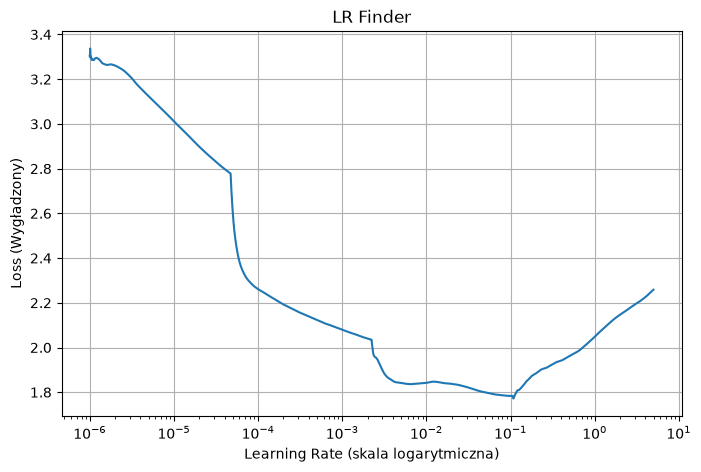

In [108]:
model5=build_ex_model_Normalized_ExtraAug()
model5.compile(optimizer=tf.keras.optimizers.Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

lrfinder=LRFinder(start_lr=1e-6, end_lr=5, max_steps=5000)
model5.fit(train32, epochs=4, callbacks=[lrfinder], shuffle=False)
lrfinder.plot()

In [109]:
model5=build_ex_model_Normalized_ExtraAug()
model5.compile(optimizer=tf.keras.optimizers.Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

batch_size=32
n_epochs=50

onecycle=OneCycleScheduler(math.ceil(len(x_train)/batch_size)*n_epochs, max_lr=6e-3)
history=model5.fit(train32, epochs=n_epochs, batch_size=batch_size, validation_data=val32, callbacks=[onecycle], shuffle=False)

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 20ms/step - accuracy: 0.3279 - loss: 1.8442 - val_accuracy: 0.4485 - val_loss: 1.5731
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.4546 - loss: 1.5100 - val_accuracy: 0.5003 - val_loss: 1.5178
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.5466 - loss: 1.2795 - val_accuracy: 0.6319 - val_loss: 1.0824
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.6022 - loss: 1.1321 - val_accuracy: 0.6435 - val_loss: 1.0504
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.6438 - loss: 1.0272 - val_accuracy: 0.6920 - val_loss: 0.8922
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.6718 - loss: 0.9489 - val_accuracy: 0.6263 - val_loss: 1.1864
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.6898 - loss: 0.8930 - val_accuracy: 0.7152 - val_loss: 0.8850
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - accuracy: 0.7041 -

In [110]:
loss, acc =model5.evaluate(test32)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9001 - loss: 0.3105


Adding extra convolutional block with maxpooling didnt improve model's score. This suggest that model's stracture and capacity is not a bottleneck here, which leads to conclusion that it's rather optimalization used and training environment.

### Trying Nesterov Momentum optimizer as Adam tends to learn quicker but gets stuck in the sharp minimas more often rather than flat minimas which lowers its ability to generalize.

Epoch 1/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.2783 - loss: 1.9673
Epoch 2/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.3955 - loss: 1.6900
Epoch 3/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.4584 - loss: 1.5193
Epoch 4/4
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.2061 - loss: 2.1560


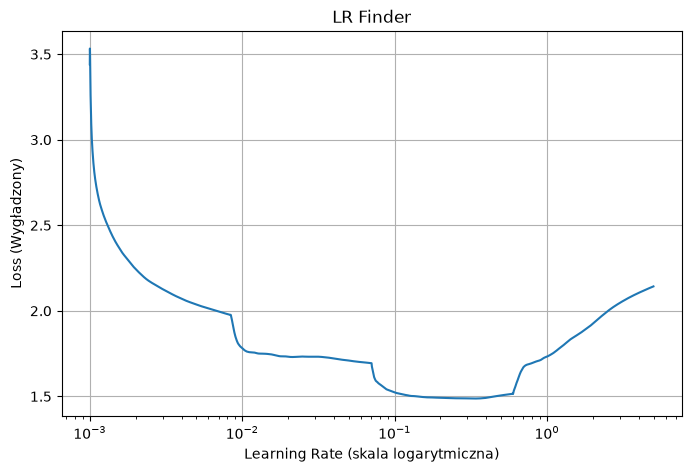

In [120]:
model6=build_ex_model_Normalized_ExtraAug()
model6.compile(optimizer=tf.keras.optimizers.SGD(momentum=0.9, nesterov=True), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

lrfinder=LRFinder(start_lr=1e-3, end_lr=5, max_steps=5000)
model6.fit(train32, epochs=4, callbacks=[lrfinder])
lrfinder.plot()

In [121]:
model6=build_ex_model_Normalized_ExtraAug()
model6.compile(optimizer=tf.keras.optimizers.SGD(momentum=0.9, nesterov=True), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

batch_size=32
n_epochs=50

onecycle=OneCycleScheduler(math.ceil(len(x_train)/batch_size)*n_epochs, max_lr=0.08)
history=model6.fit(train32, epochs=n_epochs, batch_size=batch_size, validation_data=val32, shuffle=False, callbacks=[onecycle])

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.3414 - loss: 1.8205 - val_accuracy: 0.4692 - val_loss: 1.5159
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.4792 - loss: 1.4477 - val_accuracy: 0.5514 - val_loss: 1.3718
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.5659 - loss: 1.2321 - val_accuracy: 0.6397 - val_loss: 1.0458
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.6176 - loss: 1.0837 - val_accuracy: 0.7080 - val_loss: 0.8557
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.6563 - loss: 0.9892 - val_accuracy: 0.6929 - val_loss: 0.8833
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.6830 - loss: 0.9149 - val_accuracy: 0.7219 - val_loss: 0.8307
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.7012 - loss: 0.8665 - val_accuracy: 0.7499 - val_loss: 0.7356
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.7170 -

In [122]:
model6.evaluate(test32)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9000 - loss: 0.3198


[0.31978052854537964, 0.8999999761581421]

In [124]:
model6.save_weights('CNN_Std_ExAUG_Nesterov32.weights.h5')

In [16]:
BATCH_SIZE=128
train128=train_raw.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val128=val_raw.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test128=test_raw.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Epoch 1/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.0998 - loss: 2.9485
Epoch 2/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.1057 - loss: 2.5576
Epoch 3/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.1160 - loss: 2.4217
Epoch 4/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.1485 - loss: 2.3259
Epoch 5/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.2157 - loss: 2.1313
Epoch 6/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.2946 - loss: 1.8974
Epoch 7/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.3634 - loss: 1.7213
Epoch 8/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4158 - loss: 1.5915
Epoch 9/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4645 - loss: 1.4784
Epoch 10/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5125 - loss: 1.3554
Epoch 11/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5610 - loss: 1.2463
Epoch 12/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 

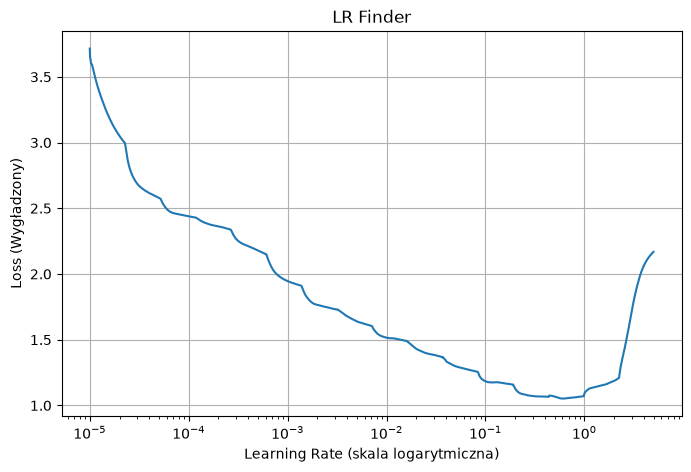

In [136]:
model7=build_ex_model_Normalized_ExtraAug()
model7.compile(optimizer=tf.keras.optimizers.SGD(momentum=0.9, nesterov=True, weight_decay = 5e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

lrfinder=LRFinder(start_lr=1e-5, end_lr=5, max_steps=5000)
model7.fit(train128, epochs=16, callbacks=[lrfinder])
lrfinder.plot()

In [143]:
model7=build_ex_model_Normalized_ExtraAug()
model7.compile(optimizer=tf.keras.optimizers.SGD(momentum=0.9, nesterov=True, weight_decay = 5e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

batch_size=128
n_epochs=100

onecycle=OneCycleScheduler(math.ceil(len(x_train)/batch_size)*n_epochs, max_lr=0.5)
history=model7.fit(train128, epochs=n_epochs, batch_size=batch_size, validation_data=val128, shuffle=False, callbacks=[onecycle])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.2598 - loss: 2.2573 - val_accuracy: 0.2509 - val_loss: 3.4177
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4006 - loss: 1.6404 - val_accuracy: 0.3978 - val_loss: 1.8871
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4731 - loss: 1.4471 - val_accuracy: 0.5208 - val_loss: 1.3509
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5343 - loss: 1.2865 - val_accuracy: 0.5679 - val_loss: 1.2704
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5899 - loss: 1.1582 - val_accuracy: 0.5685 - val_loss: 1.3001
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6322 - loss: 1.0469 - val_accuracy: 0.5788 - val_loss: 1.3999
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6630 - loss: 0.9603 - val_accuracy: 0.6812 - val_loss: 0.9652
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6824 - loss: 0.9069 - 

In [154]:
loss, acc = model7.evaluate(test128)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9116 - loss: 0.2929


In [155]:
model7.save_weights('CNN_Std_ExAUG_Nesterov128.weights.h5')

### Adding label_smoothing, second chance

Epoch 1/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.0992 - loss: 2.8012
Epoch 2/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.1029 - loss: 2.5073
Epoch 3/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.1159 - loss: 2.4352
Epoch 4/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.1426 - loss: 2.3587
Epoch 5/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.1912 - loss: 2.2433
Epoch 6/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.2603 - loss: 2.0555
Epoch 7/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.3269 - loss: 1.9220
Epoch 8/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.3898 - loss: 1.8012
Epoch 9/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4450 - loss: 1.6974
Epoch 10/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4946 - loss: 1.6075
Epoch 11/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.5478 - loss: 1.5153
Epoch 12/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 

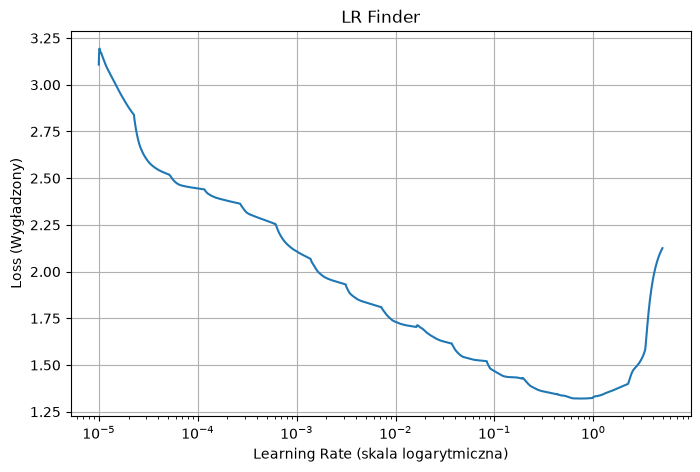

In [149]:
model8=build_ex_model_Normalized_ExtraAug()
model8.compile(optimizer=tf.keras.optimizers.SGD(momentum=0.9, nesterov=True, weight_decay = 5e-4),
               loss=sparse_cce_with_label_smoothing(num_classes=10, label_smoothing=0.1), 
                metrics=['accuracy'])

lrfinder=LRFinder(start_lr=1e-5, end_lr=5, max_steps=5000)
model8.fit(train128, epochs=16, callbacks=[lrfinder])
lrfinder.plot()

In [26]:
model8=build_ex_model_Normalized_ExtraAug()
model8.compile(optimizer=tf.keras.optimizers.SGD(momentum=0.9, nesterov=True, weight_decay = 5e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

batch_size=128
n_epochs=100

onecycle=OneCycleScheduler(math.ceil(len(x_train)/batch_size)*n_epochs, max_lr=0.8)
history=model8.fit(train128, epochs=n_epochs, batch_size=batch_size, validation_data=val128, shuffle=False, callbacks=[onecycle])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.2664 - loss: 2.2443 - val_accuracy: 0.3241 - val_loss: 2.5766
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.3947 - loss: 1.6617 - val_accuracy: 0.4658 - val_loss: 1.5256
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.4775 - loss: 1.4258 - val_accuracy: 0.4895 - val_loss: 1.5532
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.5423 - loss: 1.2645 - val_accuracy: 0.5583 - val_loss: 1.3011
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.5956 - loss: 1.1428 - val_accuracy: 0.6377 - val_loss: 1.0556
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.6260 - loss: 1.0489 - val_accuracy: 0.6336 - val_loss: 1.1301
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6600 - loss: 0.9716 - val_accuracy: 0.6541 - val_loss: 1.0534
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6789 - loss: 0.9179 - 

In [30]:
model8.evaluate(test128)

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9099 - loss: 0.3073


[0.30725207924842834, 0.9099000096321106]

In [29]:
model8.load_weights('CNN_Std_ExAUG_Nesterov128_LS.weights.h5')

Label smoothing still does not improve model's accuracy nor loss function

### Checking if data augmentation is too strong - tuning its parameters

In [51]:
class HyperModelAugTuning(kt.HyperModel):
    def build(self, hp: kt.HyperParameters):
        translation=hp.Choice('translation', [0.05, 0.08, 0.1, 0.15, 0.2])
        brightness=hp.Choice('brightness', [0.0, 0.03, 0.05, 0.1, 0.15])
        contrast=hp.Choice('contrast', [0.0, 0.03, 0.05, 0.1, 0.15])
    
        model=tf.keras.Sequential()
    
        model.add(rescale)
    
        add_expanded_data_augmentation(model, value_range=[0,1] ,translation=translation, brightness=brightness, contrast=contrast)
    
        model.add(norm)
    
        add_conv_blocks(model)
    
        for _ in range(2):
            model.add(ConvBlock(filters=256, use_bias=False))
            model.add(tf.keras.layers.BatchNormalization())
            model.add(tf.keras.layers.Activation('relu'))
            
    
        model.add(tf.keras.layers.MaxPool2D()) #2x2
        model.add(tf.keras.layers.GlobalAveragePooling2D())
        model.add(tf.keras.layers.Dense(10, activation='softmax'))
    
        model.compile(optimizer=tf.keras.optimizers.SGD(momentum=0.9, nesterov=True, weight_decay = 5e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
        return model

In [52]:
hyperband=kt.Hyperband(
    hypermodel=HyperModelAugTuning(),
    objective='val_loss',
    max_epochs=100,
    seed=42
)

In [53]:
hyperband.search(train128, batch_size=128, validation_data=val128, shuffle=False)

Trial 159 Complete [00h 00m 36s]
val_loss: 1.112013339996338

Best val_loss So Far: 0.3902251124382019
Total elapsed time: 01h 17m 24s


In [56]:
trials = hyperband.oracle.get_best_trials(num_trials=10)

for i, trial in enumerate(trials):
    print(f"\n--- Rank {i+1} ---")
    print("Trial ID:", trial.trial_id)
    print("val_loss:", trial.score)
    print("Hyperparameters:", trial.hyperparameters.values)


--- Rank 1 ---
Trial ID: 0146
val_loss: 0.3902251124382019
Hyperparameters: {'translation': 0.08, 'brightness': 0.15, 'contrast': 0.15, 'tuner/epochs': 100, 'tuner/initial_epoch': 34, 'tuner/bracket': 4, 'tuner/round': 4, 'tuner/trial_id': '0144'}

--- Rank 2 ---
Trial ID: 0147
val_loss: 0.4125724732875824
Hyperparameters: {'translation': 0.08, 'brightness': 0.05, 'contrast': 0.1, 'tuner/epochs': 100, 'tuner/initial_epoch': 34, 'tuner/bracket': 4, 'tuner/round': 4, 'tuner/trial_id': '0143'}

--- Rank 3 ---
Trial ID: 0144
val_loss: 0.48768311738967896
Hyperparameters: {'translation': 0.08, 'brightness': 0.15, 'contrast': 0.15, 'tuner/epochs': 34, 'tuner/initial_epoch': 12, 'tuner/bracket': 4, 'tuner/round': 3, 'tuner/trial_id': '0139'}

--- Rank 4 ---
Trial ID: 0143
val_loss: 0.4889005422592163
Hyperparameters: {'translation': 0.08, 'brightness': 0.05, 'contrast': 0.1, 'tuner/epochs': 34, 'tuner/initial_epoch': 12, 'tuner/bracket': 4, 'tuner/round': 3, 'tuner/trial_id': '0140'}

--- Ra

In [58]:
best_models=hyperband.get_best_models(num_models=3)

for model in best_models:
    print("Validation score")
    val_loss, val_acc = model.evaluate(val128)
    

Validation score
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8790 - loss: 0.3902
Validation score
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8722 - loss: 0.4126
Validation score
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8356 - loss: 0.4877


Epoch 1/16


/home/nagorny/miniconda3/envs/tf_gpu_wsl/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.1098 - loss: 2.4958
Epoch 2/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.1567 - loss: 2.3075
Epoch 3/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.2334 - loss: 2.0837
Epoch 4/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.3041 - loss: 1.8665
Epoch 5/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.3598 - loss: 1.7201
Epoch 6/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4084 - loss: 1.6027
Epoch 7/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4513 - loss: 1.4941
Epoch 8/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5035 - loss: 1.3790
Epoch 9/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5505 - loss: 1.2631
Epoch 10/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5878 - loss: 1.1692
Epoch 11/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6166 - loss: 1.0998
Epoch 12/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/ste

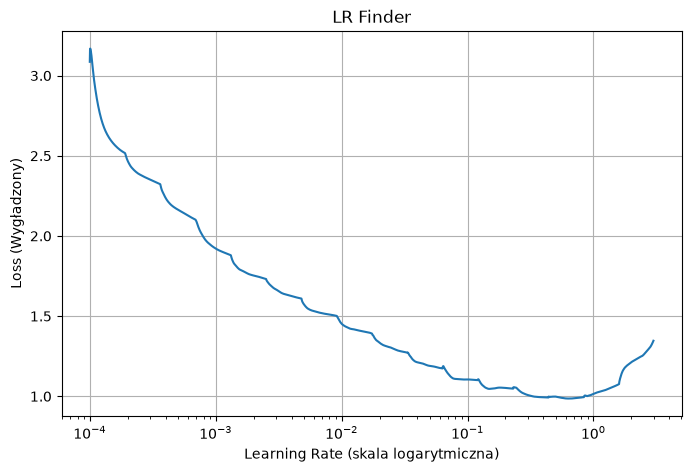

In [59]:
best_hp = hyperband.get_best_hyperparameters(1)[0]

model = hyperband.hypermodel.build(best_hp)

lrfinder=LRFinder(start_lr=1e-4, end_lr=3, max_steps=5000)
model.fit(train128, batch_size=128, epochs=16, callbacks=[lrfinder])
lrfinder.plot()

In [71]:
best_hp = hyperband.get_best_hyperparameters(1)[0]

model = hyperband.hypermodel.build(best_hp)

batch_size=128
n_epochs=200

onecycle=OneCycleScheduler(math.ceil(len(x_train)/batch_size)*n_epochs, max_lr=0.5)
history= model.fit(train128, batch_size=batch_size, epochs=n_epochs, shuffle=False, validation_data=val128, callbacks=[onecycle])

Epoch 1/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.2447 - loss: 2.3004 - val_accuracy: 0.3021 - val_loss: 2.3754
Epoch 2/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.4067 - loss: 1.6293 - val_accuracy: 0.4956 - val_loss: 1.4149
Epoch 3/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.4989 - loss: 1.3763 - val_accuracy: 0.4411 - val_loss: 1.8721
Epoch 4/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.5647 - loss: 1.2108 - val_accuracy: 0.4845 - val_loss: 1.8567
Epoch 5/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.6181 - loss: 1.0803 - val_accuracy: 0.6321 - val_loss: 1.0722
Epoch 6/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.6510 - loss: 0.9850 - val_accuracy: 0.6016 - val_loss: 1.2689
Epoch 7/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.6770 - loss: 0.9180 - val_accuracy: 0.6269 - val_loss: 1.2365
Epoch 8/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.6977 - loss: 0.8649 - 

In [72]:
model.evaluate(test128)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9175 - loss: 0.2957


[0.29566678404808044, 0.9175000190734863]

Epoch 1/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.1153 - loss: 2.5592
Epoch 2/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.1745 - loss: 2.2818
Epoch 3/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.2438 - loss: 2.0550
Epoch 4/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.3094 - loss: 1.8454
Epoch 5/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.3665 - loss: 1.7014
Epoch 6/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4159 - loss: 1.5811
Epoch 7/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4590 - loss: 1.4785
Epoch 8/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5018 - loss: 1.3728
Epoch 9/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5483 - loss: 1.2624
Epoch 10/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5893 - loss: 1.1728
Epoch 11/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6210 - loss: 1.0896
Epoch 12/16
313/313 ━━━━━━━━━━━━━━━━━━━━ 

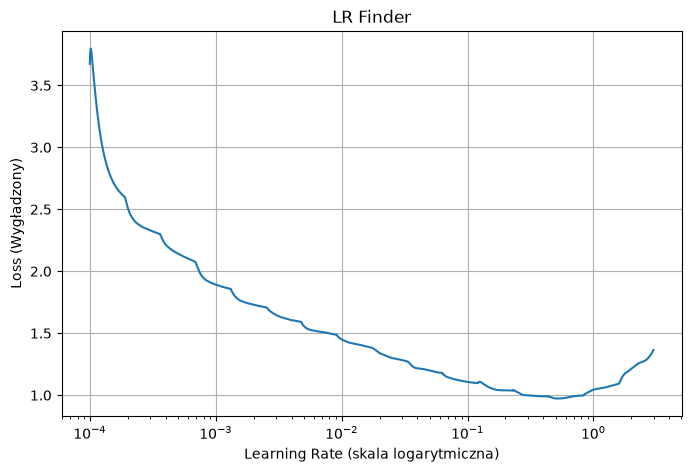

In [73]:
best_hp = hyperband.get_best_hyperparameters(5)[4]

model = hyperband.hypermodel.build(best_hp)

lrfinder=LRFinder(start_lr=1e-4, end_lr=3, max_steps=5000)
model.fit(train128, batch_size=128, epochs=16, callbacks=[lrfinder])
lrfinder.plot()

In [79]:
best_hp = hyperband.get_best_hyperparameters(5)[4]

model = hyperband.hypermodel.build(best_hp)

batch_size=128
n_epochs=300

onecycle=OneCycleScheduler(math.ceil(len(x_train)/batch_size)*n_epochs, max_lr=0.65)
history= model.fit(train128, batch_size=batch_size, epochs=n_epochs, shuffle=False, validation_data=val128, callbacks=[onecycle])

Epoch 1/300
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.2593 - loss: 2.2955 - val_accuracy: 0.2434 - val_loss: 3.1628
Epoch 2/300
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.3882 - loss: 1.6926 - val_accuracy: 0.3523 - val_loss: 1.9934
Epoch 3/300
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.4651 - loss: 1.4801 - val_accuracy: 0.4604 - val_loss: 1.7494
Epoch 4/300
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.5230 - loss: 1.3185 - val_accuracy: 0.4458 - val_loss: 1.7645
Epoch 5/300
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5714 - loss: 1.1896 - val_accuracy: 0.6365 - val_loss: 1.0314
Epoch 6/300
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6182 - loss: 1.0803 - val_accuracy: 0.6124 - val_loss: 1.1911
Epoch 7/300
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6468 - loss: 0.9956 - val_accuracy: 0.6765 - val_loss: 0.9066
Epoch 8/300
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6733 - loss: 0.9297 - 

In [80]:
model.evaluate(test128)

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9201 - loss: 0.2831


[0.28307950496673584, 0.9200999736785889]

In [81]:
model.save_weights('CNN_Std_ExAUGtuned_Nesterov128.weights.h5')

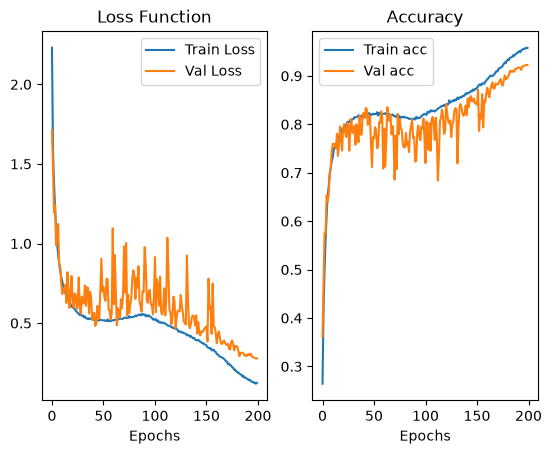

In [78]:
learning_process(history)